<a href="https://colab.research.google.com/github/bharath-hue/TASK_TNS_AIML/blob/main/Convolutional_Neural_Network_(CNN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# Reshape images to (28, 28, 1)
X_train = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_test = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Build CNN Model
model = Sequential([
    Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),

    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation='relu'
    ),

    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(10, activation='softmax')
])

# Compile Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model Summary
model.summary()

# Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

# Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test)

print(f"\nTest Accuracy: {accuracy:.4f}")
print(f"Test Loss: {loss:.4f}")

# Predict First Test Image
prediction = model.predict(X_test[:1])

print("\nPredicted Class:", prediction.argmax())
print("Actual Class:", y_test[0].argmax())

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.9180 - loss: 0.2651 - val_accuracy: 0.9787 - val_loss: 0.0728
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 32ms/step - accuracy: 0.9725 - loss: 0.0912 - val_accuracy: 0.9860 - val_loss: 0.0461
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.9796 - loss: 0.0671 - val_accuracy: 0.9847 - val_loss: 0.0511
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 31ms/step - accuracy: 0.9839 - loss: 0.0534 - val_accuracy: 0.9887 - val_loss: 0.0376
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 30ms/step - accuracy: 0.9868 - loss: 0.0445 - val_accuracy: 0.9902 - val_loss: 0.0333
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9917 - loss: 0.0249

Test Accuracy: 0.9917
Test Loss: 0.0249
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step

Predicted Class: 7
Actual Class: 7


Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.9133 - loss: 0.2843 - val_accuracy: 0.9804 - val_loss: 0.0646
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 31ms/step - accuracy: 0.9706 - loss: 0.0984 - val_accuracy: 0.9856 - val_loss: 0.0496
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - accuracy: 0.9783 - loss: 0.0706 - val_accuracy: 0.9877 - val_loss: 0.0416
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.9824 - loss: 0.0589 - val_accuracy: 0.9889 - val_loss: 0.0398
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - accuracy: 0.9855 - loss: 0.0472 - val_accuracy: 0.9902 - val_loss: 0.0358
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9912 - loss: 0.0263
Test Accuracy: 0.9911999702453613


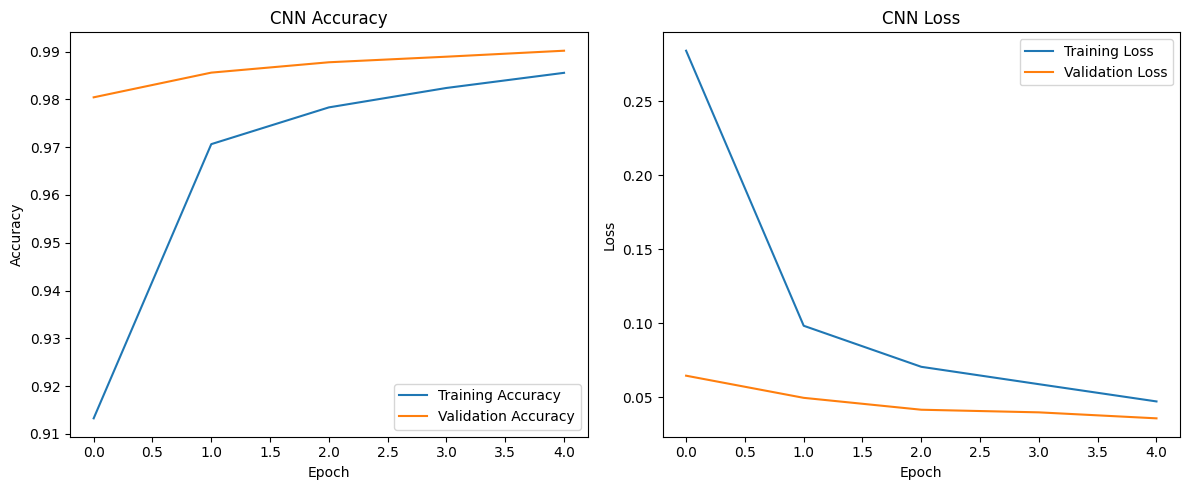

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


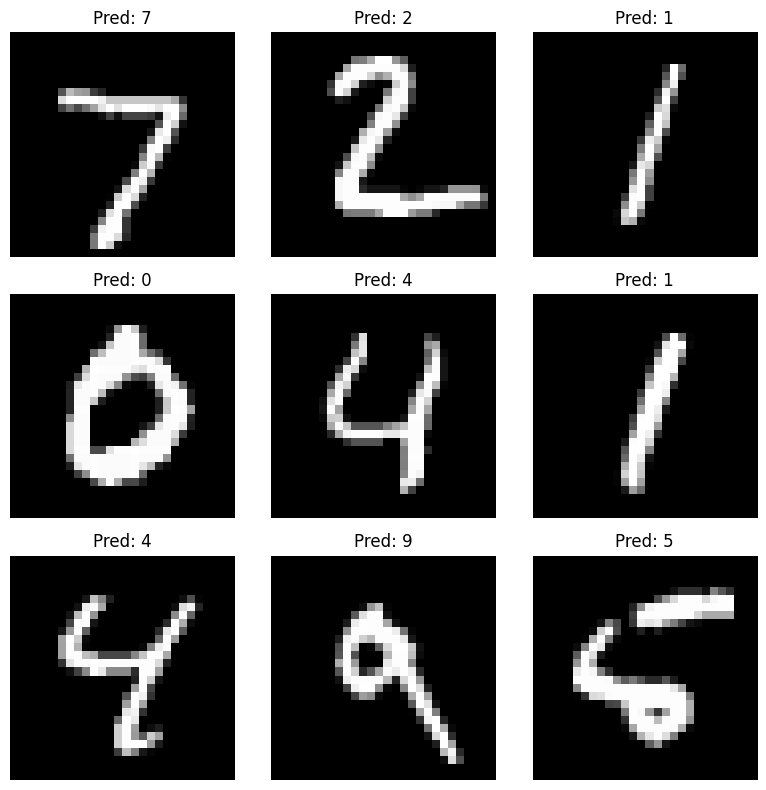

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Reshape for CNN
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# One-hot encoding
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# CNN Model
model = Sequential([
    Conv2D(32, (3,3), activation='relu',
           input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

# Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(
    X_train,
    y_train_cat,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

# Evaluate
test_loss, test_acc = model.evaluate(
    X_test,
    y_test_cat
)

print("Test Accuracy:", test_acc)

# -------------------------
# Accuracy Graph
# -------------------------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],
         label='Training Accuracy')
plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# -------------------------
# Loss Graph
# -------------------------
plt.subplot(1,2,2)
plt.plot(history.history['loss'],
         label='Training Loss')
plt.plot(history.history['val_loss'],
         label='Validation Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# -------------------------
# Visualize Predictions
# -------------------------
predictions = model.predict(X_test[:9])

plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)

    plt.imshow(
        X_test[i].reshape(28,28),
        cmap='gray'
    )

    predicted_class = np.argmax(predictions[i])

    plt.title(f"Pred: {predicted_class}")
    plt.axis('off')

plt.tight_layout()
plt.show()